### Plots of MET at gen level and detector leve using ATLAS cards

In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
import glob
import pyslha

delphesDir = os.path.abspath("../../MG5/Delphes")
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(delphesDir,"external")

import ROOT
import xml.etree.ElementTree as ET


ROOT.gSystem.Load(os.path.join(delphesDir,"libDelphes.so"))

ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 600}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=2.5)
cm = plt.cm.get_cmap('RdYlBu')

Welcome to JupyROOT 6.26/10


In [2]:
# inputFiles = {'$m_{\chi} = 300$' : ['../DMSimp_vector_0j_atlas/Events/run_01/vector_2500_300_delphes_events.root',
#                           '../DMSimp_vector_1j_atlas/Events/run_01/vector_2500_300_delphes_events.root'],
#               '$m_{\chi} = 900$' : ['../DMSimp_vector_0j_atlas/Events/run_02/vector_2500_900_delphes_events.root',
#                           '../DMSimp_vector_1j_atlas/Events/run_02/vector_2500_900_delphes_events.root']}
# inputFiles = {'$m_{\chi} = 300$' : ['../DMSimp_vector_0j_atlas_onshell/Events/run_01/vector_2500_300_delphes_events.root',
#                           '../DMSimp_vector_1j_atlas_onshell/Events/run_01/vector_2500_300_delphes_events.root'],
#               '$m_{\chi} = 900$' : ['../DMSimp_vector_0j_atlas_onshell/Events/run_03/vector_2500_900_delphes_events.root',
#                                     '../DMSimp_vector_1j_atlas_onshell/Events/run_03/vector_2500_900_delphes_events.root']}
inputFiles = {'$m_{\chi} = 300$' : ['../DMSimp_vector_0j_atlas_VF_Cal-only/Events/run_02/vector_2500_300_delphes_events.root',
                                    '../DMSimp_vector_1j_atlas_VF_Cal-only/Events/run_02/vector_2500_300_delphes_events.root']}

In [3]:
parameters = {}
for label,files in inputFiles.items():
    for file in files:
        banner = list(glob.glob(os.path.dirname(file)+'/*banner.txt'))
        if len(banner) != 1:
            print('%i banner files found for %s!' %(len(banner),label))
            continue
        else:
            banner = banner[0]
        xtree = ET.parse(banner)
        xroot = xtree.getroot()
        xsecPB = eval(xroot.find('init').text.split()[-2])
        slha = xroot.find('header').find('slha').text
        pars = pyslha.readSLHA(slha)
        mMed = pars.blocks['MASS'][55]
        mDM = pars.blocks['MASS'][52]
        gVq = pars.blocks['DMINPUTS'][4] # Mediator-quark vector coupling
        gAq = pars.blocks['DMINPUTS'][10] # Mediator-quark axial coupling
        gVx = pars.blocks['DMINPUTS'][2] # Mediator-DM vector coupling
        gAx = pars.blocks['DMINPUTS'][3] # Mediator-DM axial coupling
        parameters[label] = {'xsec(pb)' : xsecPB, 'mMed' : mMed, 'mDM' : mDM, 
                             'gVq' : gVq, 'gAq' : gAq, 'gVx' : gVx, 'gAx' : gAx}
        print(label,': mMed = %1.2f GeV, mDM = %1.2f GeV, cross-section = %1.3e pb' %(mMed,mDM,xsecPB))

$m_{\chi} = 300$ : mMed = 2500.00 GeV, mDM = 300.00 GeV, cross-section = 1.062e-01 pb
$m_{\chi} = 300$ : mMed = 2500.00 GeV, mDM = 300.00 GeV, cross-section = 9.673e-02 pb


In [14]:
### ATLAS PRESELECTION ###
## jets
pTj1min = 200.
etamax = 2.4
## MET
minMET = 300.

pTj1 = {label : np.array([]) for label in inputFiles}
weights = {label : np.array([]) for label in inputFiles}
met = {label : np.array([]) for label in inputFiles}
genMet = {label : np.array([]) for label in inputFiles}
dmPT = {label : np.array([]) for label in inputFiles}
totalweight = {label : 0.0 for label in inputFiles}
medMet = {label : np.array([]) for label in inputFiles}
weightMed = {label : np.array([]) for label in inputFiles}
trackerPT = {label : np.array([]) for label in inputFiles}

    
for label, files in inputFiles.items():
    for inputFile in files:

        f = ROOT.TFile(inputFile,'read')
        tree = f.Get("Delphes")
        nevts = tree.GetEntries()
        #     parameters[label]['Events'] = nevts

        for ievt in range(nevts):    
            
            tree.GetEntry(ievt)   
            
            particles = tree.GenParticle
            tracker = tree.Track
            
            track = []
            for it in range(tracker.GetEntries()):
                t = tracker.At(it)
                if abs(t.PID) != 52:
                    continue
#                 print(t.Charge)
                track.append(t)
            
    
            
            # Get DM particles (gen level)
            dmList = []
            for ip in range(particles.GetEntries()):
                p = particles.At(ip)
                if abs(p.PID) != 52:
                    continue
                if p.Status != 1:
                    continue
                dmList.append(p)

            if len(dmList) != 2 or len(track) != 2:
                # Skip events with Mediator -> j j
                continue
            
# #             med = []
# #             for ip in range(particles.GetEntries()):
# #                 p = particles.At(ip)
# #                 if abs(p.PID) != 55:
# #                     continue
# #                 med.append(p)

            try:
                weight = tree.Weight.At(1).Weight
            except:
                weight = tree.Weight.At(0).Weight
            
            totalweight[label] += weight
# #             weight = weight/nevts

#             missingET = tree.MissingET.At(0)
# #             genMissingET = tree.GenMissingET.At(0)  # USE REAL MISSING ET!
#             jets = tree.Jet

#             # Filter jets
#             jetList = []
#             for ijet in range(jets.GetEntries()):
#                 jet = jets.At(ijet)
#                 jetList.append(jet)  
#             jetList = sorted(jetList, key = lambda j: j.PT, reverse=True)    

# #             if len(jetList) > 0:
# #                 if jetList[0].PT < pTj1min: 
# #                     continue
# #                 deltaPhi = np.abs(jetList[0].Phi-missingET.Phi) 
# #             else:
# #                 deltaPhi = 0.0

# #             if missingET.MET < minMET:
# #                 continue
            

# #             if len(med) > 0:
# # #                 print(med[-1].Status)
# #                 medMet[label] = np.append(medMet[label],med[-1].PT)
# #                 weightMed[label] = np.append(weightMed[label],weight)
#             # Store relevant data        
            dmPT[label] = np.append(dmPT[label],np.sqrt((dmList[0].Px + dmList[1].Px)**2 
                                                        + (dmList[0].Py + dmList[1].Py)**2))
            
# #             if len(jetList) > 0:
# #                 pTj1[label] = np.append(pTj1[label], jetList[0].PT)

            weights[label] = np.append(weights[label],weight)
#             met[label] = np.append(met[label],missingET.MET)
#             genMet[label] = np.append(genMet[label],genMissingET.MET)
            trackerPT[label] = np.append(trackerPT[label], track[0].PT)

        f.Close()

In [15]:
for label,w in totalweight.items():
    print(label,'total cross-section = %1.3e pb' %(w))
colors = {label : sns.color_palette('deep')[i+1] for i,label in enumerate(weights.keys())}   

$m_{\chi} = 300$ total cross-section = 8.197e-02 pb


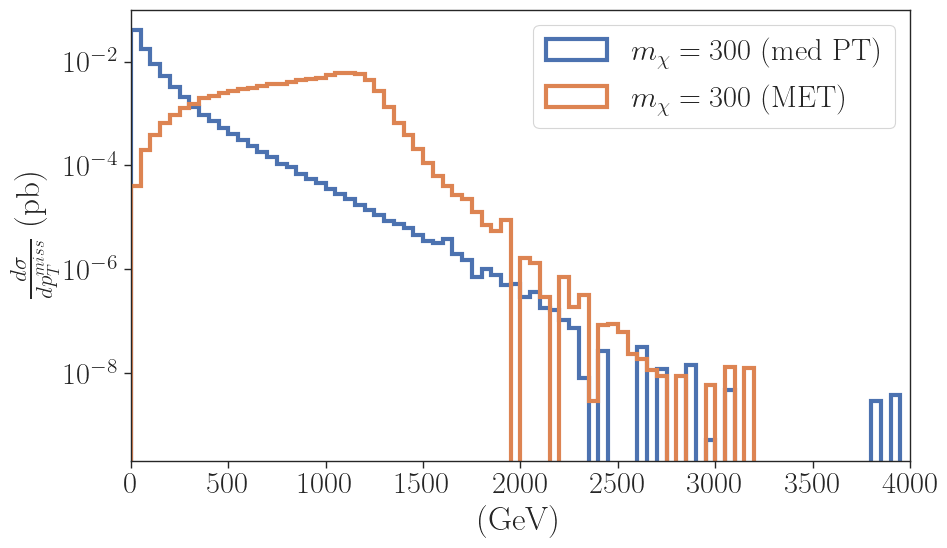

In [17]:
fig = plt.figure(figsize=(10,6))
for label,metPts in dmPT.items():
    binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
                               label=label+' (gen MET)',histtype='step',
                               weights=weights[label],linewidth=3, density=False)

for label,pTj in trackerPT.items():
    binc,binEdges,patches = plt.hist(pTj,bins=np.linspace(0,5000,101),
                               label=label+' (MET)',histtype='step',linewidth=3, density=False,
                                    weights=weights[label])
    
        
    
plt.yscale('log')
# plt.ylim(1e-3,1)
plt.xlabel(r'(GeV)')
plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
plt.xlim(0,4000)
plt.tight_layout()
plt.legend()
# plt.savefig('met-vs-medpt-atlas.png')
plt.show()

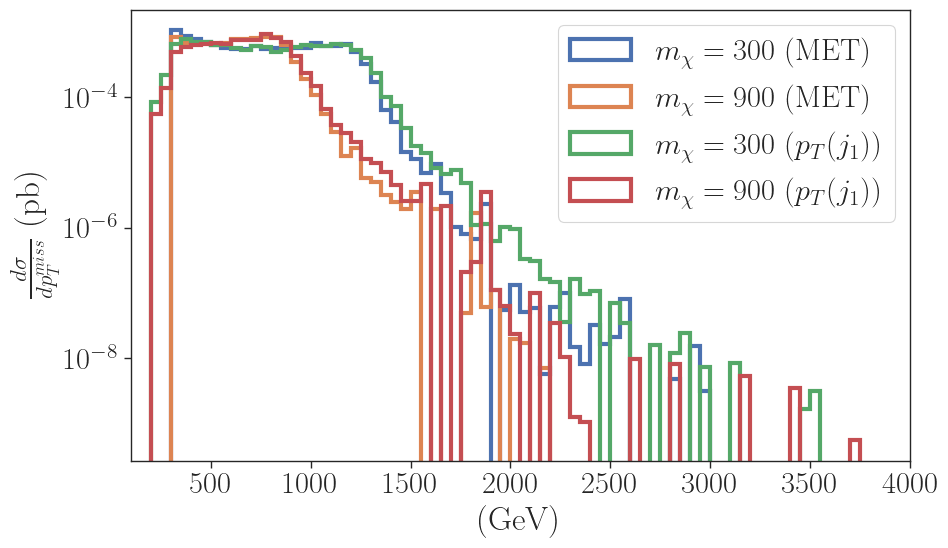

In [14]:
fig = plt.figure(figsize=(10,6))
for label,metPts in met.items():
    binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
                               label=label+' (MET)',histtype='step',
                               weights=weights[label],linewidth=3)

for label,pTj in pTj1.items():
    binc,binEdges,patches = plt.hist(pTj,bins=np.linspace(0,5000,101),
                               label=label+' ($p_{T}(j_{1})$)',histtype='step',
                               weights=weights[label],linewidth=3)
    
        
    
plt.yscale('log')
# plt.ylim(1e-3,1)
plt.xlabel(r'(GeV)')
plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
plt.xlim(100,4000)
plt.tight_layout()
plt.legend()
# plt.savefig('met-vs-pt-atlas.png')
plt.show()

In [16]:
1.408326e+02/2500

0.05633304000000001

In [37]:
2.773745e+01/2500

0.011094979999999999

In [35]:
massPairs = [300., 2500.]

gx = 0.1
GMratio = 0.01
gq_with_top = np.sqrt((4*np.pi*GMratio - ((gx**2)/3)*(1-(1*massPairs[0]**2/massPairs[1]**2))*(1-(4*massPairs[0]**2/massPairs[1]**2))**(1/2)) / (5 + (1 - (1-(4*172**2/massPairs[1]**2))**(3/2))))
gq_no_top = np.sqrt((4*np.pi*GMratio - ((gx**2)/3)*(1-(1*massPairs[0]**2/massPairs[1]**2))*(1-(4*massPairs[0]**2/massPairs[1]**2))**(1/2)) / 5)
gqValues = gq_with_top if massPairs[1] > 2*172 else gq_no_top

In [36]:
gqValues

0.15606788190889948

In [21]:
(1-(4*massPairs[0]**2/massPairs[1]**2))

0.9424

In [22]:
4*np.pi*GMratio

0.12566370614359174

In [24]:
(1/3)*(1-(4*massPairs[0]**2/massPairs[1]**2))**(3/2)

0.30495212320479276

In [27]:
48/12

4.0